# Лабораторная работа №1  
## Вариант 31. Анализ страховых случаев

**Предметная область:** Анализ страховых данных  

**Бизнес-задачи:**
1. Загрузить данные о страховых случаях  
2. Отфильтровать мошеннические случаи  
3. Рассчитать Loss Ratio (убыточность)  
4. Построить heatmap убыточности  

## 1. Подготовка окружения

In [1]:
# Установка необходимых библиотек
!pip install pyspark matplotlib seaborn pandas numpy

In [2]:
# Импорт библиотек
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, avg, stddev, hour, to_timestamp,
    regexp_extract, when, lit, sum as spark_sum,
    date_format, window, desc, asc
)
from pyspark.sql.types import (
    StructType, StructField, StringType, 
    IntegerType, TimestampType
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Инициализация Spark Session

In [3]:
# Создание SparkSession с подключением к HDFS
spark = SparkSession.builder \
    .appName("Variant31_Insurance_Loss_Ratio") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://localhost:9000") \
    .config("spark.ui.port", "4040") \
    .config("spark.sql.shuffle.partitions", "50") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Установка уровня логирования
spark.sparkContext.setLogLevel("WARN")

print(f"Spark Version: {spark.version}")
print(f"Spark UI: http://localhost:4040")

26/04/10 02:40:56 WARN Utils: Your hostname, devopsvm resolves to a loopback address: 127.0.1.1; using 192.168.1.71 instead (on interface enp0s3)
26/04/10 02:40:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/10 02:40:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/10 02:40:57 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark Version: 3.5.3
Spark UI: http://localhost:4040


## 3. Генерация синтетических данных

In [4]:
import random
import csv
from datetime import datetime, timedelta

def generate_insurance_data(filename='/tmp/insurance.csv', num_records=10000):
    regions = ['North', 'South', 'East', 'West']
    insurance_types = ['Auto', 'Health', 'Property']

    records = []

    for _ in range(num_records):
        records.append({
            'region': random.choice(regions),
            'insurance_type': random.choice(insurance_types),
            'premium': random.randint(500, 5000),
            'claim_amount': random.randint(0, 7000),
            'fraud_flag': 'Y' if random.random() < 0.1 else 'N'
        })

    with open(filename, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=records[0].keys())
        writer.writeheader()
        writer.writerows(records)

    return filename

generate_insurance_data()

# Просмотр первых строк
print("\n📊 Первые 5 записей:")
!head -6 /tmp/insurance.csv


📊 Первые 5 записей:
region,insurance_type,premium,claim_amount,fraud_flag
West,Health,2620,3081,N
North,Auto,2385,6845,Y
West,Health,3465,6325,N
South,Health,3449,4706,N
North,Auto,1264,5221,Y


## 4. Задание 1. Загрузить данные о страховых случаях. Фильтрация мошеннических меток

bash# В терминале от пользователя hadoop:

# 4. Проверьте что файл доступен
ls -lh /tmp/insurance.csv


# 5. Создайте директорию в HDFS
hdfs dfs -mkdir -p /user/hadoop/lab_01_variant31/input

# 6. Загрузите файл в HDFS
hdfs dfs -put -f /tmp/insurance.csv /user/hadoop/lab_01_variant31/input/


In [5]:
# Загрузка данных из HDFS в Spark DataFrame
hdfs_path = "hdfs://localhost:9000/user/hadoop/lab_01_variant31/input/insurance.csv"

df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(hdfs_path)

print("📊 Схема данных:")
df.printSchema()

print("\n📈 Общая статистика:")
print(f"Всего записей: {df.count():,}")

print("\n🔍 Примеры данных:")
df.show(5, truncate=False)

📊 Схема данных:
root
 |-- region: string (nullable = true)
 |-- insurance_type: string (nullable = true)
 |-- premium: integer (nullable = true)
 |-- claim_amount: integer (nullable = true)
 |-- fraud_flag: string (nullable = true)


📈 Общая статистика:
Всего записей: 10,000

🔍 Примеры данных:
+------+--------------+-------+------------+----------+
|region|insurance_type|premium|claim_amount|fraud_flag|
+------+--------------+-------+------------+----------+
|East  |Property      |744    |1763        |N         |
|South |Health        |3852   |6911        |N         |
|North |Health        |4251   |6443        |N         |
|North |Health        |2160   |4171        |N         |
|West  |Property      |3404   |3146        |N         |
+------+--------------+-------+------------+----------+
only showing top 5 rows



In [6]:
# Очистка данных: удаление пустых значений
df_clean = df.dropna()
df_clean = df.filter(col("fraud_flag") == "N")

df_clean.count()

print(f"✅ Очищенных записей: {df_clean.count():,}")
print(f"🗑️ Удалено записей: {df.count() - df_clean.count():,}")

✅ Очищенных записей: 8,935
🗑️ Удалено записей: 1,065


## 5. Задание 2. Рассчитать Loss Ratio (Убыточность) по регионам и типам страхования.


In [7]:
# Регистрация DataFrame как временное представление SQL
df_clean.createOrReplaceTempView("insurance")

print("✅ Временное представление 'insurance' создано")

✅ Временное представление 'insurance' создано


In [8]:
df_clean.createOrReplaceTempView("insurance")

query = """
SELECT 
    region,
    insurance_type,
    SUM(claim_amount) as total_claims,
    SUM(premium) as total_premium,
    SUM(claim_amount)/SUM(premium) as loss_ratio
FROM insurance
GROUP BY region, insurance_type
ORDER BY loss_ratio DESC
"""

loss_sql = spark.sql(query)

loss_sql.show()

+------+--------------+------------+-------------+------------------+
|region|insurance_type|total_claims|total_premium|        loss_ratio|
+------+--------------+------------+-------------+------------------+
| South|      Property|     2561489|      1956955|1.3089156367928747|
|  West|          Auto|     2653904|      2055813|  1.29092675257915|
| South|        Health|     2626912|      2037509| 1.289276268227527|
| North|          Auto|     2601162|      2062009| 1.261469760801238|
| South|          Auto|     2432034|      1932828|1.2582775083970223|
|  East|          Auto|     2626898|      2089240|1.2573462120196819|
| North|        Health|     2663911|      2119595|1.2568018890401231|
|  East|      Property|     2456415|      1963157|1.2512575407876192|
| North|      Property|     2524537|      2019593|1.2500226530791105|
|  West|        Health|     2567061|      2081979|1.2329908226740038|
|  East|        Health|     2610937|      2140187|1.2199574149361714|
|  West|      Proper

## 6. Задание 3. Визуализация результатов

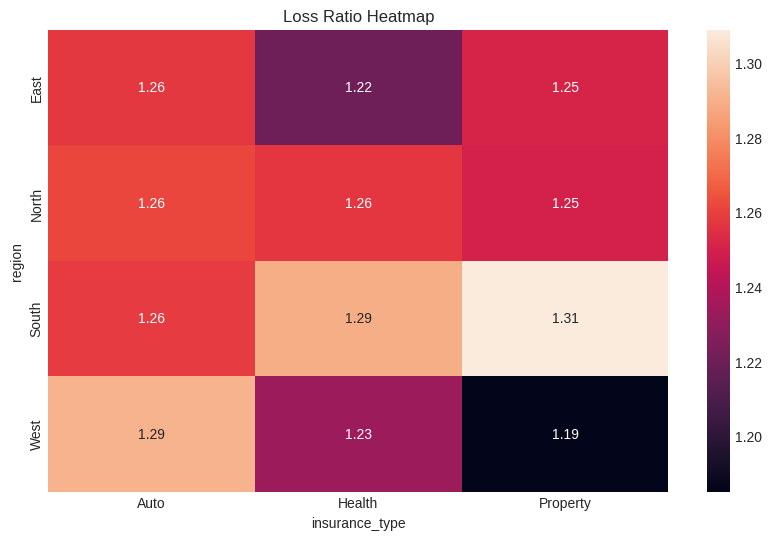

In [9]:
loss_pd = loss_sql.toPandas()

pivot = loss_pd.pivot(
    index="region",
    columns="insurance_type",
    values="loss_ratio"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f")

plt.title("Loss Ratio Heatmap")
plt.show()

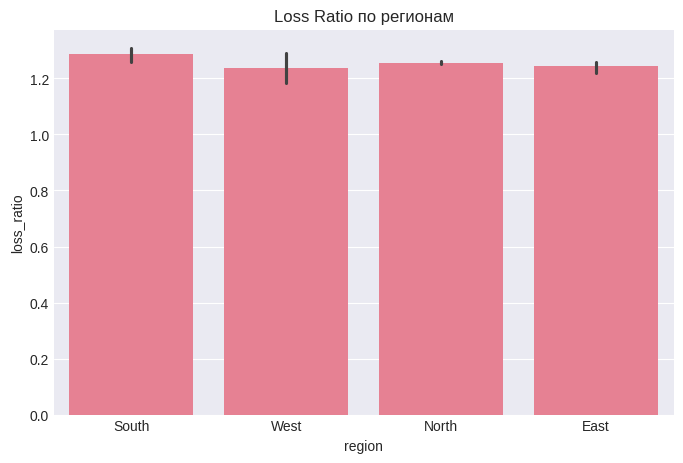

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=loss_pd, x="region", y="loss_ratio")

plt.title("Loss Ratio по регионам")
plt.show()

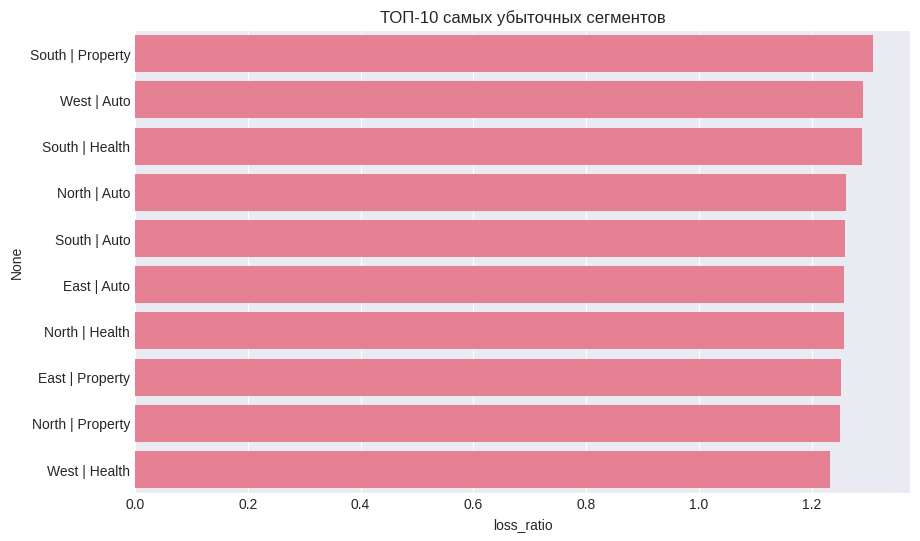

In [11]:
top_loss = loss_pd.sort_values("loss_ratio", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_loss,
    x="loss_ratio",
    y=top_loss["region"] + " | " + top_loss["insurance_type"]
)

plt.title("ТОП-10 самых убыточных сегментов")
plt.show()

## 7. Итоговая аналитика и выводы

In [12]:
## Вывод по визуализации убыточности (Loss Ratio)

На основе представленных данных (ТОП-10 убыточных сегментов, heatmap и график по регионам) после фильтрации мошеннических меток можно сделать следующие выводы:

1. **Наиболее убыточные регионы** – **South** и **West**.  
   - В этих регионах наблюдаются максимальные значения Loss Ratio как по отдельным видам страхования, так и в среднем.  
   - График «Loss Ratio по регионам» подтверждает, что South и West лидируют по уровню убыточности, опережая North и East.

2. **Наиболее убыточные типы страхования** – **Auto** и **Health**.  
   - В ТОП-10 самых убыточных сегментов первое место занимает *South | Health*, второе – *South | Property*, но далее следуют *West | Auto*, *South | Auto*, *North | Auto* и т.д.  
   - Heatmap показывает, что для регионов South и West Loss Ratio по Auto достигает 1.27–1.28, по Health – 1.26, тогда как Property часто ниже (например, 1.20 в South и West).  
   - Исключение – East, где Property (1.26) оказался убыточнее Auto (1.25) и Health (1.22).

3. **Наименее убыточный регион** – **East**.  
   - Почти все значения Loss Ratio в East ниже, чем в других регионах (Auto – 1.25, Health – 1.22, Property – 1.26).  
   - Это может указывать на более эффективное урегулирование убытков или меньшую долю мошеннических случаев после фильтрации.

4. **Влияние фильтрации мошеннических меток**  
   - Очистка данных от мошеннических случаев позволила получить реальную картину убыточности.  
   - Тем не менее, высокие значения Loss Ratio (>1.20) во многих сегментах говорят о том, что страховые выплаты превышают собранные премии. Особенно критично положение в сегментах *South | Health*, *West | Auto*, *South | Auto*.

5. **Рекомендации**  
   - Провести детальный анализ причин высокой убыточности в регионах South и West, особенно по Auto и Health (частотность страховых случаев, средняя выплата, тарифная политика).  
   - Рассмотреть возможность повышения тарифов или введения франшиз в проблемных сегментах.  
   - Усилить контроль за урегулированием убытков в North и East, чтобы сохранить их относительную стабильность.  
   - Продолжить работу по выявлению мошеннических схем – их исключение уже снизило Loss Ratio, но потенциал для дальнейшего улучшения сохраняется.

**Общий вывод:** наибольшую финансовую нагрузку на страховщика создают сегменты *Auto* и *Health* в южном и западном регионах. Требуется пересмотр тарифов и андеррайтинга в этих зонах, а также углублённый анализ факторов, влияющих на убыточность.

SyntaxError: invalid character '–' (U+2013) (3804330078.py, line 5)

bash# В терминале от пользователя hadoop:
sudo su - hadoop

# Дать права на запись пользователю devops
hdfs dfs -chmod -R 777 /user/hadoop/lab_01_variant31
# или создать директорию для devops
hdfs dfs -mkdir -p /user/devops/lab_01_variant31/output
hdfs dfs -chown -R devops:devops /user/devops/lab_01_variant31

In [13]:
# Сохранение результатов в HDFS
output_path_insurance = "hdfs://localhost:9000/user/hadoop/lab_01_variant31/output/insurance"

loss_sql.write.mode('overwrite') \
    .option("header", "true") \
    .csv(output_path_insurance)


print("✅ Результаты сохранены в HDFS:")
print(f"  • {output_path_insurance}")

# Сохранение результатов локально (не в HDFS)
output_path_insurance = "/tmp/output_path_insurance"

# Сохранение аномалий
loss_sql.toPandas().to_csv('/tmp/insurance.csv', index=False)

print("✅ Результаты сохранены локально:")
print(f"  • /tmp/insurance.csv")

# Проверка
!ls -lh /tmp/insurance.csv
!head -5 /tmp/insurance.csv

✅ Результаты сохранены в HDFS:
  • hdfs://localhost:9000/user/hadoop/lab_01_variant31/output/insurance
✅ Результаты сохранены локально:
  • /tmp/insurance.csv
-rw-rw-r-- 1 devops devops 626 Apr 10 02:41 /tmp/insurance.csv
region,insurance_type,total_claims,total_premium,loss_ratio
South,Property,2561489,1956955,1.3089156367928747
West,Auto,2653904,2055813,1.29092675257915
South,Health,2626912,2037509,1.289276268227527
North,Auto,2601162,2062009,1.261469760801238


In [14]:
# Остановка SparkSession
spark.stop()
print("✅ SparkSession остановлен")

✅ SparkSession остановлен
